In [1]:
import sys
sys.path.append('..')

In [2]:
import pandas as pd
from utils.data_enedis_ademe import DataEnedisAdeme

#### Consommation d'électricité annuelle résidentielle par adresse

*Le jeu de données présente la consommation électrique annuelle des adresses de 10 logements ou plus. Un logement correspond à un point de livraison (ou PDL) de type résidentiel.<br>Les données sont mises à disposition à titre purement indicatif sans garantie quant au degré de fiabilité des adresses. Enedis ne saurait, par conséquent, être tenue responsable en cas de défaut de fiabilité.<br>À partir de 2021 et suite à un changement dans le référentiel des adresses, la normalisation de celles-ci peut faire apparaitre des écarts avec les années précédentes.*

In [3]:
tmp_url = "https://data.enedis.fr/api/explore/v2.1/catalog/datasets/consommation-annuelle-residentielle-par-adresse/records?select=segment_de_client%2C%20annee%2C%20count\
    (code_iris)%20as%20nb%2C%20min(nombre_de_logements)%20as%20nb_min_logements%2C%20max(nombre_de_logements)%20as%20nb_max_logements&group_by=segment_de_client%2C%20annee&limit=20"

DataEnedisAdeme().load_get_data_pandas(tmp_url)

,segment_de_client,annee,nb,nb_min_logements,nb_max_logements
0,RESIDENTIEL,2018-01-01T00:00:00+00:00,391099,10,1189
1,RESIDENTIEL,2019-01-01T00:00:00+00:00,399791,10,1124
2,RESIDENTIEL,2020-01-01T00:00:00+00:00,405605,10,1435
3,RESIDENTIEL,2021-01-01T00:00:00+00:00,407053,10,1189
4,RESIDENTIEL,2022-01-01T00:00:00+00:00,394100,10,1190
5,RESIDENTIEL,2023-01-01T00:00:00+00:00,397398,10,1196


*Avec ceci on voit que les adresses Enedis sont des logements 'residentiels' avec au moins 10 logements et au plus +de 1000 logements. Une fois la correspondance faite avec la base de l'ADEME - DPE depuis 2021 on le dataset suivant :*

In [4]:
db = DataEnedisAdeme()
tmp_df = db.extract_sample_year_rows(year=2018, rows=5)
tmp_df.head(3)

AttributeError: 'DataEnedisAdeme' object has no attribute 'extract_sample_year_rows'

*Echantillon pour l'étude : périmètre Paris 2018*

In [4]:
df = pd.read_parquet('../ressources/data/2_intermediary/enedis_ban_ademe_extract_PARIS_2018_400k_rows_250_min_comp.parquet', engine='pyarrow')
df.head()

,Conso_chauffage_dépensier_é_finale_ademe,Volume_stockage_générateur_ECS_n°1_ademe,Conso_é_finale_installation_ECS_ademe,Nom__commune_(BAN)_ademe,Emission_GES_chauffage_ademe,Conso_ECS_é_finale_énergie_n°2_ademe,Conso_ECS_é_finale_énergie_n°1_ademe,Besoin_refroidissement_ademe,Conso_chauffage_dépensier_installation_chauffage_n°1_ademe,Coût_total_5_usages_ademe,...,y_enedis_with_ban,city_enedis_with_ban,district_enedis_with_ban,context_enedis_with_ban,type_enedis_with_ban,importance_enedis_with_ban,street_enedis_with_ban,lon_enedis_with_ban,lat_enedis_with_ban,_type_enedis_with_ban
0,16170.8,0.0,1548.3,Paris,2987.6,0.0,1548.3,0,16170.8,1083.0,...,6866570.89,Paris,Paris 17e Arrondissement,"75, Paris, Île-de-France",housenumber,0.66547,Passage Flourens,2.327087,48.897252,None
1,20081.5,0.0,5617.0,Paris,3737.2,0.0,5617.0,0,20081.5,2150.5,...,6866570.89,Paris,Paris 17e Arrondissement,"75, Paris, Île-de-France",housenumber,0.66547,Passage Flourens,2.327087,48.897252,None
2,38501.7,0.0,5812.1,Paris,10285.3,0.0,5812.1,0,38501.7,3529.6,...,6863733.09,Paris,Paris 16e Arrondissement,"75, Paris, Île-de-France",housenumber,0.77255,Avenue Foch,2.278373,48.871447,address
3,39468.7,0.0,6130.1,Paris,10508.7,0.0,6130.1,0,39468.7,3637.1,...,6863733.09,Paris,Paris 16e Arrondissement,"75, Paris, Île-de-France",housenumber,0.77255,Avenue Foch,2.278373,48.871447,address
4,15376.1,0.0,5752.4,Paris,2816.4,0.0,5752.4,0,15376.1,1186.5,...,6863783.96,Paris,Paris 16e Arrondissement,"75, Paris, Île-de-France",housenumber,0.77255,Avenue Foch,2.282777,48.871931,None


# Exploration

In [5]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 465961 entries, 0 to 465960
Columns: 280 entries, Conso_chauffage_dépensier_é_finale_ademe to _type_enedis_with_ban
dtypes: float64(144), int64(7), object(129)
memory usage: 995.4+ MB


In [7]:
df.isna().any()[df.isna().any()==True].index.to_list()

['Volume_stockage_générateur_ECS_n°1_ademe',
 'Conso_é_finale_installation_ECS_ademe',
 'Conso_ECS_é_finale_énergie_n°2_ademe',
 'Besoin_refroidissement_ademe',
 'Conso_chauffage_dépensier_installation_chauffage_n°1_ademe',
 'Coût_total_5_usages_ademe',
 'Configuration_installation_chauffage_n°1_ademe',
 'Conso_é_finale_dépensier_installation_ECS_ademe',
 'Configuration_installation_ECS_ademe',
 'Type_installation_chauffage_n°1_ademe',
 'Surface_chauffée_installation_chauffage_n°1_ademe',
 'Nombre_niveau_logement_ademe',
 'Apports_internes_saison_froid_ademe',
 'Type_installation_ECS_(général)_ademe',
 'Déperditions_murs_ademe',
 'Conso_5_usages_par_m²_é_primaire_ademe',
 'Usage_générateur_ECS_n°1_ademe',
 'Coût_ECS_dépensier_ademe',
 'Emission_GES_auxiliaires_ademe',
 'Emission_GES_5_usages_par_m²_ademe',
 'Apports_solaires_saison_froid_ademe',
 'N°_étage_appartement_ademe',
 'Type_énergie_générateur_ECS_n°1_ademe',
 'Coût_ECS_ademe',
 'Surface_habitable_desservie_par_installation_ECS

In [8]:
df["Tri des adresses_enedis_with_ban"].dtypes


dtype('int64')

In [9]:
class preprocessing :
    def __init__(self, df):
        self.df = df.copy()
        self.cast_object_columns_step = False #???
        
    def get_entropy(self, pk, L):
        op= - (pk * np.log(pk) / np.log(L)).sum()
        return op

    def delete_colnan (self, tauxseuil):
        print("delete_colnan")
        print("Le dataframe contient initialement {} colonnes et {} lignes.".format(len(self.df.columns), len(self.df)))
        print("Start processing : columns identification ...")
        nanames = []
        entro = []
        extra = ["Code_INSEE_(BAN)_ademe","Code IRIS_enedis_with_ban","Code_postal_(brut)_ademe","Code_postal_(BAN)_ademe","Numéro de voie_enedis_with_ban",
                "Nombre de logements_enedis_with_ban","Tri des adresses_enedis_with_ban","postcode_enedis_with_ban","citycode_enedis_with_ban"]
        for c in self.df.columns:
            tauxnan = round(self.df[c].isna().sum()/len(self.df),2)
            pk = df[c].value_counts(normalize=True, dropna = False).values
            entropy = round(self.get_entropy(pk, len(self.df)),2)
            if tauxnan >= tauxseuil:
                nanames.append(c)
                # print("***", c, "***")
                # print(tauxnan)
            if c[0]=="_" and "geo" not in c:
                extra.append(c)
            if entropy == 1 or entropy == 0:
                entro.append(c)
        print("Il y a {} colonnes vides à, au moins, {}% , {} colonnes avec une entropy de 0 ou 1 et {} colonnes inutiles".format(len(nanames),tauxseuil*100, len(entro), len(extra)))
        print("Start processing : columns deleting ...")
        self.df=self.df.drop(nanames+entro+extra, axis=1).drop_duplicates()
        print("Done deleting columns")
        print("Il reste {} colonnes et {} lignes.".format(len(self.df.columns), len(self.df)))
        print(self.df.info())
        return self

    
    def cast_object_columns(self):
        print("Start processing : columns encoding ...")
        if not self.cast_object_columns_step:
            cols_obj = self.df.select_dtypes(include='O').columns
            for c in cols_obj:
                # self.df[c] = self.df[c].str.replace(',', '.')
                # self.df[c] = self.df[c].fillna(-999999)
                try:
                    self.df[c] = pd.to_numeric(self.df[c].str.replace(',','.'), errors='raise')
                except Exception as e:
                    try:
                        self.df[c] = pd.to_datetime(self.df[c])
                    except Exception as e:
                        self.df[c] = self.df[c].astype('string')
            print("Casting done...")
            self.cast_object_columns_step = True
        print(self.df.info())
        print("done cast_object_columns")
        return self
    

    def fillnan(self):
        # print("fillnan")
        print(self.df.info())
        # col_fill_median = []
        # col_fill_mean = []
        for col in self.df.select_dtypes(include ='float').columns:
            if self.df[col].isna().any():
                # print(self.df[col].dtypes)
                Q1 = self.df[col].quantile(0.25)
                Q3 = self.df[col].quantile(0.75)
                IQR = Q3 - Q1
                born_inf =(self.df[col]<(Q1-1.5*IQR)).value_counts()
                born_sup = (self.df[col]>(Q3+1.5*IQR)).value_counts()
                try:
                    born_inf[1]
                    #col_fill_median.append(col)
                    self.df[col].fillna(self.df[col].median(), inplace=True )
                    # print("le type",self.df[col].dtypes)
                except Exception as e:
                    try:
                        born_sup[1]
                        #col_fill_median.append(col)
                        self.df[col].fillna(self.df[col].median(), inplace=True)
                        # print("le type",self.df[col].dtypes)
                    except Exception as e:
                        #col_fill_mean.append(col)
                        # self.df[col].fillna(self.df[col].mean, inplace=True)
                        self.df[col] = self.df[col].fillna(self.df[col].mean())
                        # print("le type",self.df[col].dtypes)
        # print("le nomnbre de colonnes traitées:", len(df.select_dtypes(['int','float']).columns))
        # print(len(col_fill_median))
        # print(len(col_fill_mean))
        # print(self.df.info())
        print("done fillnan")
        return self

In [10]:
df_clean = preprocessing(df).delete_colnan(0.9).cast_object_columns().fillnan().df
df_clean_col = df_clean.drop(columns=df_clean.select_dtypes(include='datetime').columns)
df_clean_col.info()

delete_colnan
Le dataframe contient initialement 280 colonnes et 465961 lignes.
Start processing : columns identification ...
Il y a 76 colonnes vides à, au moins, 90.0% , 55 colonnes avec une entropy de 0 ou 1 et 14 colonnes inutiles
Start processing : columns deleting ...
Done deleting columns
Il reste 174 colonnes et 437073 lignes.
<class 'pandas.core.frame.DataFrame'>
Index: 437073 entries, 0 to 465960
Columns: 174 entries, Conso_chauffage_dépensier_é_finale_ademe to lat_enedis_with_ban
dtypes: float64(104), object(70)
memory usage: 583.6+ MB
None
Start processing : columns encoding ...
Casting done...
<class 'pandas.core.frame.DataFrame'>
Index: 437073 entries, 0 to 465960
Columns: 174 entries, Conso_chauffage_dépensier_é_finale_ademe to lat_enedis_with_ban
dtypes: datetime64[ns](4), float64(106), string(64)
memory usage: 583.6 MB
None
done cast_object_columns
<class 'pandas.core.frame.DataFrame'>
Index: 437073 entries, 0 to 465960
Columns: 174 entries, Conso_chauffage_dépensier_é

Les colonnes suivantes ont une corrélation supérieure à 0.9 : ['Emission_GES_chauffage_ademe', 'Coût_total_5_usages_ademe', 'Conso_é_finale_dépensier_installation_ECS_ademe', 'Emission_GES_éclairage_ademe', 'Conso_ECS_dépensier_é_finale_ademe', 'Coût_ECS_ademe', 'Surface_habitable_desservie_par_installation_ECS_ademe', 'Coût_éclairage_ademe', 'Coût_total_5_usages_énergie_n°1_ademe', 'Conso_refroidissement_é_finale_ademe', 'Conso_chauffage_é_primaire_ademe', 'Conso_éclairage_é_primaire_ademe', 'Emission_GES_5_usages_énergie_n°1_ademe', 'Emission_GES_ECS_énergie_n°1_ademe', 'Conso_5_usages_é_finale_ademe', 'Conso_refroidissement_é_primaire_ademe', 'Emission_GES_ECS_dépensier_ademe', 'Emission_GES_chauffage_énergie_n°1_ademe', 'Conso_é_finale_dépensier_générateur_ECS_n°1_ademe', 'Emission_GES_refroidissement_ademe', 'Emission_GES_ECS_ademe', 'Coût_ECS_énergie_n°2_ademe', 'Coût_ECS_énergie_n°1_ademe', 'Conso_ECS_é_finale_ademe', 'Emission_GES_5_usages_ademe', 'Conso_éclairage_é_finale_adem

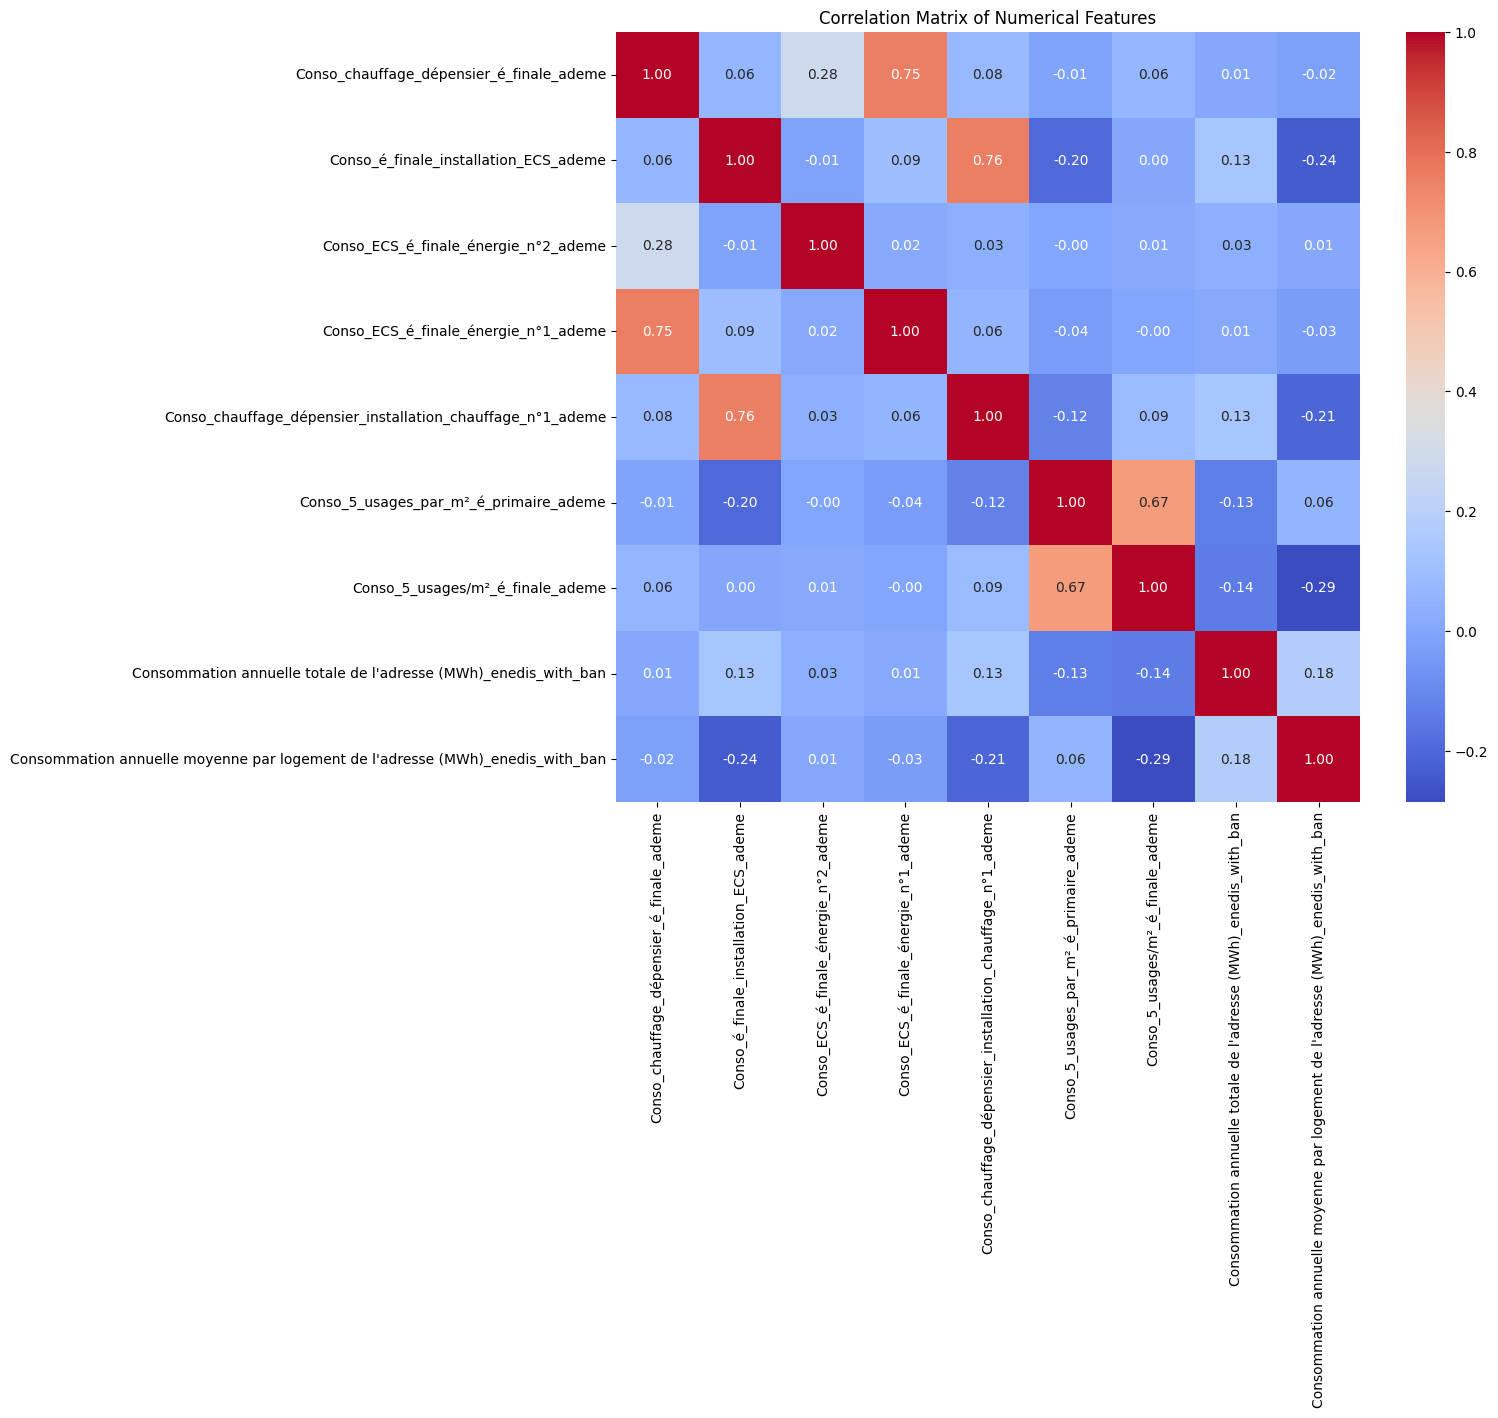

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

def clean_correlation(df, seuil):

    col = [c for c in df.select_dtypes("float").columns ]
    correlation_matrix = df[col].corr()

    threshold = seuil  # le seuil de colinéarité
    upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

    # Trouver les colonnes ayant une corrélation supérieure au seuil
    to_drop = [column for column in upper_triangle.columns if any(abs(upper_triangle[column]) > threshold)]
    print(f"Les colonnes suivantes ont une corrélation supérieure à {threshold} : {to_drop}")

    # Supprimer les colonnes colinéaires
    df = df.drop(columns=to_drop)

    print(f"Les colonnes suivantes ont été supprimées : {to_drop}")
    print(f'il reste {len(df.columns)} colonnes')

    conso_clean_col = [c for c in df.columns if "conso" in c.lower()]
    correlation_matrix = df[conso_clean_col].corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix of Numerical Features')
    # plt.show()
    return df

df_clean = clean_correlation(df_clean_col, 0.9)

In [13]:
# garder l'arrondissement
import re
def extract_digit(x):
    return re.sub(r'\D', '', str(x))

df_clean["arrondissement"] = df_clean["district_enedis_with_ban"].apply(extract_digit).astype('string')

In [14]:
to_drop = ["district_enedis_with_ban","street_enedis_with_ban", "name_enedis_with_ban", "id_BAN_enedis_with_ban", "housenumber_enedis_with_ban", "label_enedis_with_ban", "full_adress_enedis_with_ban",
           "adresse_enedis_with_ban","Libellé de voie_enedis_with_ban", "Type de voie_enedis_with_ban", "Nom IRIS_enedis_with_ban", "N°_DPE_immeuble_associé_ademe", "Nom__rue_(BAN)_ademe",
           "Identifiant__BAN_ademe","Complément_d'adresse_bâtiment_ademe", "Adresse_brute_ademe", "N°DPE_ademe", "N°_voie_(BAN)_ademe", "Complément_d'adresse_logement_ademe",
           "Adresse_(BAN)_ademe","_geopoint_ademe","Statut_géocodage_ademe", "Description_installation_ECS_ademe", "Description_générateur_ECS_n°1_ademe",
           "Description_générateur_chauffage_n°1_installation_n°1_ademe", "Description_installation_chauffage_n°1_ademe", "score_enedis_with_ban", "x_enedis_with_ban", "y_enedis_with_ban","importance_enedis_with_ban"]

df_clean.drop(to_drop, axis=1, inplace=True)
print(f'il reste {len(df_clean.columns)} colonnes')

il reste 88 colonnes


In [15]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 437073 entries, 0 to 465960
Data columns (total 88 columns):
 #   Column                                                                         Non-Null Count   Dtype  
---  ------                                                                         --------------   -----  
 0   Conso_chauffage_dépensier_é_finale_ademe                                       437073 non-null  float64
 1   Volume_stockage_générateur_ECS_n°1_ademe                                       437073 non-null  float64
 2   Conso_é_finale_installation_ECS_ademe                                          437073 non-null  float64
 3   Conso_ECS_é_finale_énergie_n°2_ademe                                           437073 non-null  float64
 4   Conso_ECS_é_finale_énergie_n°1_ademe                                           437073 non-null  float64
 5   Besoin_refroidissement_ademe                                                   437073 non-null  float64
 6   Conso_chauffage_d

In [20]:
df_clean['Type_installation_chauffage_n°1_ademe'].value_counts()

Type_installation_chauffage_n°1_ademe
installation individuelle                                                                                       244392
installation collective                                                                                         160068
installation collective multi-bâtiment : modélisée comme un réseau de chaleur                                    19410
installation hybride collective-individuelle (chauffage base + appoint individuel ou convecteur bi-jonction)      2112
Name: count, dtype: Int64

In [21]:
df_clean['Type_installation_chauffage_ademe'].value_counts()

Type_installation_chauffage_ademe
individuel                      238822
collectif                       166610
mixte (collectif-individuel)     30053
Name: count, dtype: Int64

In [ ]:
from sklearn.preprocessing import LabelBinarizer
#Inertie_lourde_(0/1)_ademe,Logement_traversant_(0/1)_ademe,Présence_brasseur_air_(0/1)_ademe,Protection_solaire_exterieure_(0/1)_ademe,Logement_traversant_(0/1)_ademe,Isolation_toiture_(0/1)_ademe,Appartement_non_visité_(0/1)_ademe
lb = LabelBinarizer()
lb.fit_transform()

In [17]:
# encoding
for col in df_clean.columns:
    print(df_clean[col].value_counts())

# Configuration_installation_chauffage_n°1_ademe, Configuration_installation_ECS_ademe, 
# Type_installation_chauffage_n°1_ademe, Type_installation_ECS_(général)_ademe
# Usage_générateur_ECS_n°1_ademe, N°_étage_appartement_ademe, Type_énergie_générateur_ECS_n°1_ademe,
# Type_générateur_ECS_n°1_ademe, ,ualité_isolation_menuiseries_ademe,
# Qualité_isolation_murs_ademe, Type_émetteur_installation_chauffage_n°1_ademe,
# Méthode_application_DPE_ademe, Période_construction_ademe,Indicateur_confort_été_ademe,
# Type_énergie_n°1_ademe,Type_énergie_n°2_ademe, Type_installation_ECS_ademe,
# ,Qualité_isolation_plancher_haut_comble_perdu_ademe,
# Type_bâtiment_ademe,,Usage_générateur_n°1_installation_n°1_ademe,
# Version_DPE_ademe, Type_énergie_générateur_n°1_installation_n°1_ademe, Type_installation_chauffage_ademe,
# Type_énergie_principale_chauffage_ademe, ,Qualité_isolation_enveloppe_ademe,
# , Etiquette_GES_ademe,Etiquette_DPE_ademe,Type_générateur_n°1_installation_n°1_ademe,
# Qualité_isolation_plancher_bas_ademe,Type_énergie_principale_ECS_ademe, Année_construction_ademe,
# Catégorie_ENR_ademe,Qualité_isolation_plancher_haut_toit_terrase_ademe,
# , type_enedis_with_ban


Conso_chauffage_dépensier_é_finale_ademe
0.0        229
10275.9    193
2042.2     184
1540.0     168
4667.2     155
          ... 
17586.3      1
19761.9      1
13766.6      1
12006.8      1
18078.1      1
Name: count, Length: 172510, dtype: int64
Volume_stockage_générateur_ECS_n°1_ademe
0.0      186373
100.0     65192
50.0      31638
150.0     29650
75.0      21171
          ...  
187.8         1
336.3         1
182.0         1
230.9         1
91.9          1
Name: count, Length: 2038, dtype: int64
Conso_é_finale_installation_ECS_ademe
1877.85       13123
1.00           6766
1269675.40     1000
573101.20       998
475866.40       914
              ...  
2785.90           1
3665.70           1
3335.90           1
818.30            1
7952.80           1
Name: count, Length: 48174, dtype: int64
Conso_ECS_é_finale_énergie_n°2_ademe
0.0         385127
4220.2         132
961.7          126
163743.9        92
4515.2          88
             ...  
836.1            1
1046.4           1
2419.2 

In [22]:
len(df_clean.columns)
df_clean.head()

,Conso_chauffage_dépensier_é_finale_ademe,Volume_stockage_générateur_ECS_n°1_ademe,Conso_é_finale_installation_ECS_ademe,Conso_ECS_é_finale_énergie_n°2_ademe,Conso_ECS_é_finale_énergie_n°1_ademe,Besoin_refroidissement_ademe,Conso_chauffage_dépensier_installation_chauffage_n°1_ademe,Configuration_installation_chauffage_n°1_ademe,Configuration_installation_ECS_ademe,Type_installation_chauffage_n°1_ademe,...,Type_énergie_principale_ECS_ademe,Année_construction_ademe,Catégorie_ENR_ademe,Qualité_isolation_plancher_haut_toit_terrase_ademe,Nombre_niveau_immeuble_ademe,Appartement_non_visité_(0/1)_ademe,Consommation annuelle totale de l'adresse (MWh)_enedis_with_ban,Consommation annuelle moyenne par logement de l'adresse (MWh)_enedis_with_ban,type_enedis_with_ban,arrondissement
0,16170.8,0.0,1548.3,0.0,1548.3,0.0,16170.8,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation collective,...,Gaz naturel,1948.0,<NA>,<NA>,8.0,<NA>,23.715,1.694,housenumber,17
1,20081.5,0.0,5617.0,0.0,5617.0,0.0,20081.5,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation collective,...,Gaz naturel,1948.0,<NA>,<NA>,8.0,<NA>,23.715,1.694,housenumber,17
2,38501.7,0.0,5812.1,0.0,5812.1,0.0,38501.7,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation collective,...,Fioul domestique,1948.0,<NA>,<NA>,8.0,<NA>,41.505,2.965,housenumber,16
3,39468.7,0.0,6130.1,0.0,6130.1,0.0,39468.7,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation collective,...,Fioul domestique,1948.0,<NA>,<NA>,8.0,<NA>,41.505,2.965,housenumber,16
4,15376.1,0.0,5752.4,0.0,5752.4,0.0,15376.1,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation collective,...,Gaz naturel,1948.0,<NA>,<NA>,8.0,<NA>,138.919,1.561,housenumber,16


In [26]:
round(df_clean["Type_bâtiment_ademe"].value_counts(normalize=True, dropna = False),2)

Type_bâtiment_ademe
appartement    0.98
immeuble       0.01
maison          0.0
Name: proportion, dtype: Float64

In [27]:
round(df_clean["Etiquette_DPE_ademe"].value_counts(normalize=True, dropna = False),3)

Etiquette_DPE_ademe
E    0.289
D    0.274
C    0.151
F     0.15
G    0.129
B    0.006
A      0.0
Name: proportion, dtype: Float64

In [25]:
# from scipy.stats import chi2_contingency

# def clean_chi2(df):
#     indep_features = []
#     #x = df.drop("Consommation annuelle moyenne par logement de l'adresse (MWh)_enedis_with_ban", axis=1)

#     # Étape 1 : Création d'un tableau croisé pour deux variables
#     for c in df.drop("Consommation annuelle moyenne par logement de l'adresse (MWh)_enedis_with_ban", axis=1).columns:
#         print(c)
#         contingency_table = pd.crosstab(df["Consommation annuelle moyenne par logement de l'adresse (MWh)_enedis_with_ban"], df[c])

#         # Étape 2 : Test du chi-carré
#         chi2, p, dof, expected = chi2_contingency(contingency_table)

#         # Affichage des résultats
#         print("\np-valeur :", p)

#         # Interprétation
#         if p < 0.05:
#             print("\nLa variable {} est dépendante (relation significative).".format(str(c)))
#         else:
#             print("\nLa variable {} est indépendante (pas de relation significative).".format(str(c)))
#             indep_features.append(c)

#     df.drop(columns=indep_features, inplace=True, axis=1)
#     print("le nombre de colonnes finales \n:",len(df.columns))
#     return df

# test_clean_chi2 = clean_chi2(test_clean)

Conso_chauffage_dépensier_é_finale_ademe

p-valeur : 0.0

La variable Conso_chauffage_dépensier_é_finale_ademe est dépendante (relation significative).
Volume_stockage_générateur_ECS_n°1_ademe

p-valeur : 0.0

La variable Volume_stockage_générateur_ECS_n°1_ademe est dépendante (relation significative).
Conso_é_finale_installation_ECS_ademe

p-valeur : 0.0

La variable Conso_é_finale_installation_ECS_ademe est dépendante (relation significative).
Conso_ECS_é_finale_énergie_n°2_ademe

p-valeur : 0.0

La variable Conso_ECS_é_finale_énergie_n°2_ademe est dépendante (relation significative).
Conso_ECS_é_finale_énergie_n°1_ademe

p-valeur : 0.0

La variable Conso_ECS_é_finale_énergie_n°1_ademe est dépendante (relation significative).
Besoin_refroidissement_ademe

p-valeur : 0.0

La variable Besoin_refroidissement_ademe est dépendante (relation significative).
Conso_chauffage_dépensier_installation_chauffage_n°1_ademe

p-valeur : 0.0

La variable Conso_chauffage_dépensier_installation_chauffa

: 

In [ ]:
# nettoyage des outliers

# col_fill_median = []
# col_fill_mean = []
# for col in df.select_dtypes(['int','float']).columns:
#     #print(col)
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1
#     # print(IQR, Q1-1.5*IQR, Q3+1.5*IQR)
#     # data_clean = data_clean[~((data_clean[col]<(Q1-1.5*IQR))|(data_clean[col]>(Q3+1.5*IQR)))]
#     # print((df[col]<(Q1-1.5*IQR)).value_counts(), (df[col]>(Q3+1.5*IQR)).value_counts())
#     born_inf =(df[col]<(Q1-1.5*IQR)).value_counts()
#     born_sup = (df[col]>(Q3+1.5*IQR)).value_counts()
#     try:
#         born_inf[1]
#         col_fill_median.append(col)
#     except Exception as e:
#         try:
#             born_sup[1]
#             col_fill_median.append(col)
#         except Exception as e:
#             # print("il n'y a que des False")
#             col_fill_mean.append(col)
# # print("le nomnbre de colonnes traitées:", len(df.select_dtypes(['int','float']).columns))
# # print(len(col_fill_median))
# # print(len(col_fill_mean))
# for col in df.select_dtypes(['int','float']).columns:
#     if col in col_fill_mean:
#         df[col].fillna(df[col].mean, inplace=True)
#     if col in col_fill_median:
#         df[col].fillna(df[col].median, inplace=True)
#     else:
#         print(col)
#         # print("il y a un probleme")



_rand_ademe
Année_enedis_with_ban
code_commune_enedis_with_ban
Consommation annuelle moyenne de la commune (MWh)_enedis_with_ban
Code EPCI_enedis_with_ban
Code Département_enedis_with_ban
Code Région_enedis_with_ban
Tri des adresses_enedis_with_ban
x_enedis_with_ban
y_enedis_with_ban
lon_enedis_with_ban
lat_enedis_with_ban


In [ ]:
# # recherches des valeurs manquantes
# def get_entropy(pk, L):
#     op = - (pk * np.log(pk) / np.log(L)).sum()
#     return op

# tauxseuil = 0.9
# nanames = []
# entro = []
# extra =[]
# print("Le dataframe contient initialement {} colonnes et {}".format(len(df.columns), len(df)))
# for c in df.columns:
#     tauxnan = round(df[c].isna().sum()/len(df),2)
#     pk = df[c].value_counts(normalize=True, dropna = False).values
#     entropy = round(get_entropy(pk, len(df)),2)
#     if tauxnan >= tauxseuil:
#         nanames.append(c)
#     if c[0]=="_" and "geo" not in c:
#         #print(c)
#         extra.append(c)
#         #print("***", c, "***")
#         #print(tauxnan)
#     if entropy == 1 or entropy == 0:
#         # print(c, entropy)
#         nanames.append(c)
#         entro.append(c)
# print("Il y a {} colonnes vides avec au moins {}% , {} colonnes avec une entropy de 1 ou 0 et {} colonnes inutiles.".format(len(nanames),tauxseuil*100, len(entro), len(extra)))
# # print(len(df.columns))
# # print(nanames)
# df_clean = df.copy().drop(nanames+entro+extra, axis=1).drop_duplicates()
# print("Il reste {} colonnes et {} lignes.".format(len(df_clean.columns),len(df_clean)))

Le dataframe contient initialement 280 colonnes et 465961
_rand_ademe
_i_ademe
_score_ademe
_id_ademe
_type_enedis_with_ban
Il y a 131 colonnes vides avec au moins 90.0% , 55 colonnes avec une entropy de 1 ou 0 et 5 colonnes inutiles.
Il reste 183 colonnes et 437073 lignes.


In [15]:
# import numpy as np
# def get_entropy(pk, L):
#         op = - (pk * np.log(pk) / np.log(L)).sum()
#         return op 
# # pk : probabilité de chaque valeur
# # L : nombre de valeurs possibles
# # d : dataframe
# # cols : liste des colonnes à traiter

# def compute_entropies(d, cols):
#     entropies = []
#     for i,col in enumerate(cols):
#         pk = d[col].value_counts(normalize=True, dropna = False).values
#         entropy = round(get_entropy(pk, len(d)),3)
#         entropies.append({"col": col, "entropy": entropy})
#     return entropies      

# df_entropy = pd.DataFrame(compute_entropies(df_clean, df_clean.columns))

In [16]:
# df_entropy.sort_values(by="entropy", ascending=True).head(50)

,col,entropy
177,type_enedis_with_ban,0.004
76,Emission_GES_refroidissement_ademe,0.007
96,Type_bâtiment_ademe,0.007
95,Emission_GES_refroidissement_dépensier_ademe,0.008
20,Coût_refroidissement_ademe,0.008
65,Conso_refroidissement_é_primaire_ademe,0.009
92,Coût_refroidissement_dépensier_ademe,0.009
46,Conso_refroidissement_é_finale_ademe,0.009
130,Conso_refroidissement_dépensier_é_primaire_ademe,0.010
105,Conso_refroidissement_dépensier_é_finale_ademe,0.010


In [41]:
for c in df_clean.select_dtypes("string").columns:
    # print(c,)
    print(df_clean[c].value_counts(), "\n")

Configuration_installation_chauffage_n°1_ademe
Installation de chauffage simple                                                                                                                         423566
Installation de chauffage collectif avec Base + appoint                                                                                                    1860
Convecteurs bi-jonction                                                                                                                                     294
Installation de chauffage avec insert ou poêle bois en appoint                                                                                              160
Installation de chauffage avec chaudière en relève de PAC                                                                                                    65
Installation de chauffage avec en appoint un insert ou poêle bois et un chauffage électrique dans la salle de bain (différent du chauffage principal)    

In [28]:
for c in df_cleaned_float.columns:
    if "adresse_" in c.lower():
        print(c)

NameError: name 'df_cleaned_float' is not defined

<BarContainer object of 7 artists>

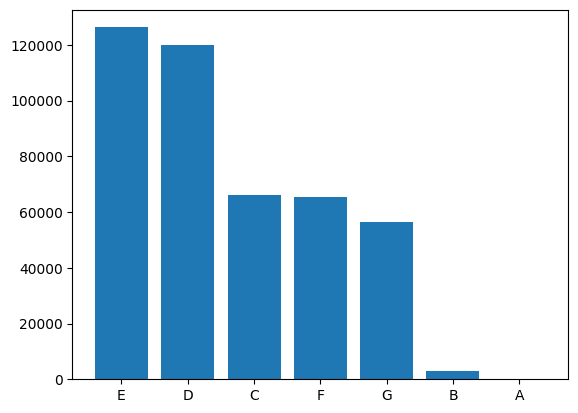

In [87]:
# distribution des logements en fonction des DPE
import matplotlib.pyplot as plt
import numpy as np

DPE = df_clean["Etiquette_DPE_ademe"].value_counts().index
count = df_clean["Etiquette_DPE_ademe"].value_counts()
fig, ax = plt.subplots()
ax.bar(DPE,count)

<Axes: >

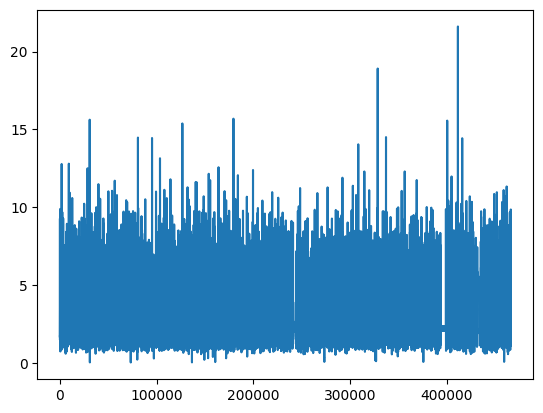

In [162]:
df["Consommation annuelle moyenne par logement de l'adresse (MWh)_enedis_with_ban"].plot()

<Axes: >

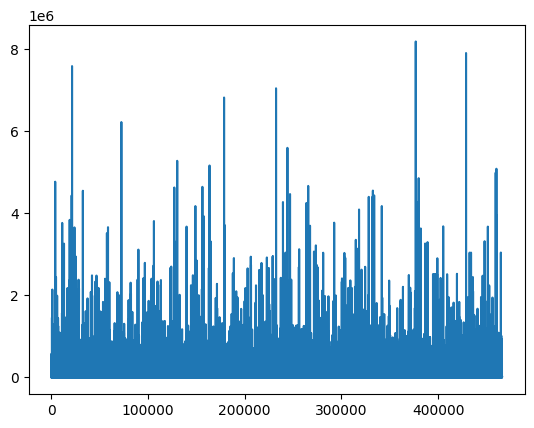

In [88]:
df["Conso_5_usages_é_primaire_ademe"].plot()

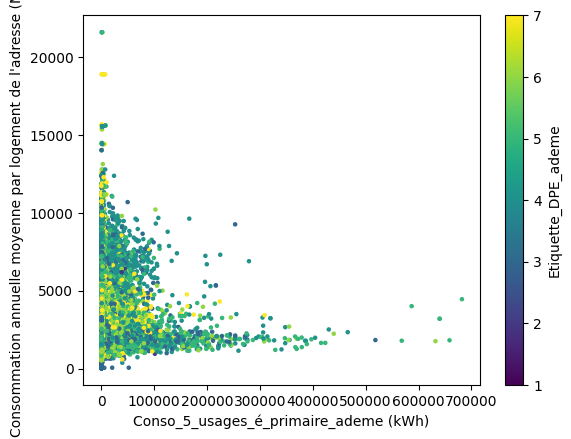

In [74]:
import matplotlib.pyplot as plt

# Convert categorical data to numerical values
color_mapping = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
colors = df_clean["Etiquette_DPE_ademe"].map(color_mapping)

plt.scatter(
    (df_clean["Conso_5_usages_é_primaire_ademe"]/12 ).round(2),
    df_clean["Consommation annuelle moyenne par logement de l'adresse (MWh)_enedis_with_ban"]*1000,
    c=colors,
    cmap='viridis',
    s=5)

plt.xlabel("Conso_5_usages_é_primaire_ademe (kWh)")
plt.ylabel("Consommation annuelle moyenne par logement de l'adresse (MWh)")
plt.colorbar(label='Etiquette_DPE_ademe')
plt.show()

In [107]:
(df_clean[["Conso_5_usages_é_primaire_ademe"]]/12).describe().round(3)
# Conso_5_usages_é_primaire_ademe : consommation annuelle  5 usages (ecs/chauffage/climatisation/eclairage/auxiliaires)en 
# energie finale(déduit de la production pv autoconsommée)  (kWhef/an)


,Conso_5_usages_é_primaire_ademe
count,437072.000
mean,1683.389
std,7836.890
min,34.875
25%,663.725
50%,976.592
75%,1391.708
max,681998.742


In [108]:
(df_clean[ ["Consommation annuelle moyenne par logement de l'adresse (MWh)_enedis_with_ban"]]*1000).describe().round(3)

,Consommation annuelle moyenne par logement de l'adresse (MWh)_enedis_with_ban
count,437073.000
mean,2942.075
std,1506.101
min,30.000
25%,1868.000
50%,2661.000
75%,3538.000
max,21607.000
